In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

path = '../data/subject-83'

df = pd.read_csv(path + ".tsv", sep='\t')
df.replace(['NA', 'undefined'], np.nan, inplace=True)
df['TIME'] = pd.to_numeric(df['TIME'], errors='coerce')
df['dx']   = pd.to_numeric(df['FPOGX'], errors='coerce')
df['dy']   = pd.to_numeric(df['FPOGY'], errors='coerce')
df['FPOGV'] = pd.to_numeric(df['FPOGV'], errors='coerce')
df = df.dropna(subset=['dx', 'dy']).sort_values('TIME').reset_index(drop=True)

csv = pd.read_csv(path + ".csv")

onsets     = df[df['USER'].notna() & df['USER'].str.contains('IMAGE_ONSET', na=False)]
img_markers = df[df['USER'].notna() & df['USER'].str.contains('IMG_LEFT', na=False)][['TIME', 'USER']]

segments = []
for i, (_, row) in enumerate(onsets.iterrows()):
    t0  = row['TIME']
    seg = df[(df['TIME'] >= t0) & (df['TIME'] < t0 + 5.0) & (df['FPOGV'] == 1) &
             (df['dx'] >= 0) & (df['dx'] <= 1) & (df['dy'] >= 0) & (df['dy'] <= 1)].copy()
    seg['t_rel'] = seg['TIME'] - t0
    img_row = img_markers[img_markers['TIME'] <= t0].tail(1)
    label   = img_row['USER'].values[0].strip() if len(img_row) else ''
    img_left  = label.split('IMG_LEFT=')[1].split(' ')[0]  if 'IMG_LEFT='  in label else '?'
    img_right = label.split('IMG_RIGHT=')[1].split(' ')[0] if 'IMG_RIGHT=' in label else '?'
    r = csv.iloc[i]
    # 実際の画像位置 (pixel)
    lx = int(960 + r['x_left']);  ly = int(540 + r['y_left'])
    rx = int(960 + r['x_right']); ry = int(540 + r['y_right'])
    segments.append({'seg': seg, 'img_left': img_left, 'img_right': img_right,
                     'left_px': (lx, ly), 'right_px': (rx, ry),
                     'csv_side': r['first_fix_side'], 'csv_rt': r['first_fix_rt']})

print(f'{len(segments)} trials loaded')

8 trials loaded


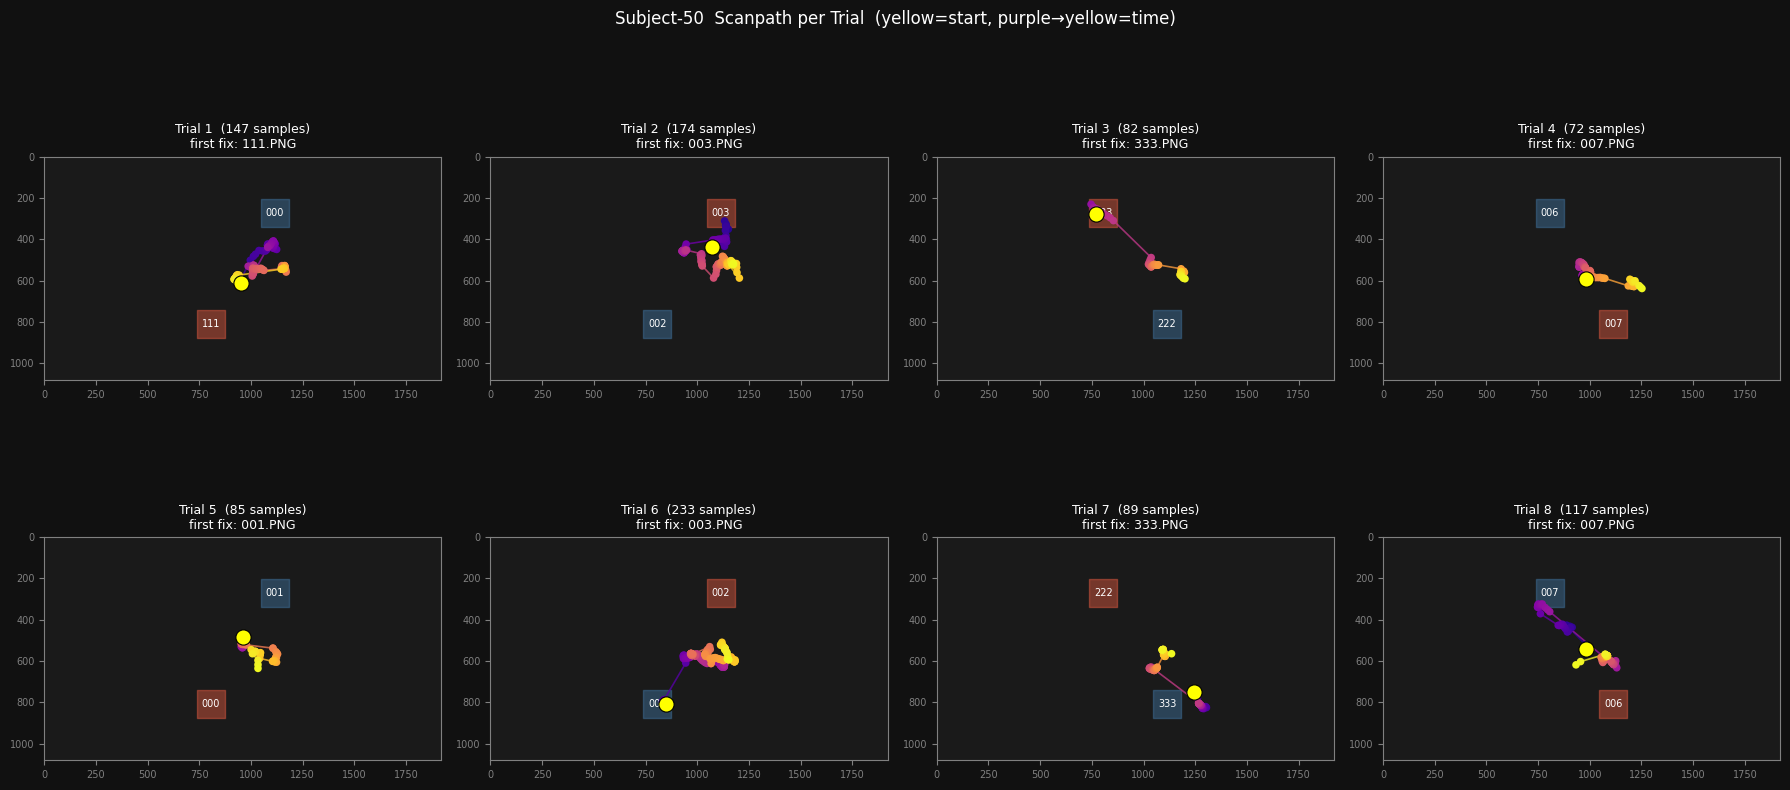

In [39]:
SCREEN_W, SCREEN_H = 1920, 1080

fig, axes = plt.subplots(2, 4, figsize=(18, 9))

for i, trial in enumerate(segments):
    ax  = axes[i // 4, i % 4]
    seg = trial['seg']
    lx, ly = trial['left_px']
    rx, ry = trial['right_px']

    ax.set_xlim(0, SCREEN_W)
    ax.set_ylim(SCREEN_H, 0)
    ax.set_facecolor('#1a1a1a')
    ax.set_aspect('equal')

    ax.scatter([lx], [ly], s=400, marker='s', color='steelblue', alpha=0.4, zorder=1, label=f'L:{trial["img_left"]}')
    ax.scatter([rx], [ry], s=400, marker='s', color='tomato',    alpha=0.4, zorder=1, label=f'R:{trial["img_right"]}')
    ax.text(lx, ly, trial['img_left'].replace('.PNG',''),  ha='center', va='center', fontsize=7, color='white')
    ax.text(rx, ry, trial['img_right'].replace('.PNG',''), ha='center', va='center', fontsize=7, color='white')

    if len(seg) >= 2:
        xs = seg['dx'].values * SCREEN_W
        ys = seg['dy'].values * SCREEN_H
        n  = len(xs)
        colors = cm.plasma(np.linspace(0, 1, n))

        for j in range(n - 1):
            ax.plot([xs[j], xs[j+1]], [ys[j], ys[j+1]], color=colors[j], lw=1.2, alpha=0.8)

        ax.scatter(xs, ys, c=np.linspace(0, 1, n), cmap='plasma',
                   s=30, zorder=5, edgecolors='none')

        ax.scatter([xs[0]], [ys[0]], s=120, color='yellow', zorder=6, edgecolors='black', linewidths=0.8)

    elif len(seg) == 1:
        xs = seg['dx'].values * SCREEN_W
        ys = seg['dy'].values * SCREEN_H
        ax.scatter(xs, ys, s=120, color='yellow', zorder=6, edgecolors='black', linewidths=0.8)

    first_img = 'unclear'
    if len(seg) >= 1:
        for xi, yi in zip(seg['dx'].values * SCREEN_W, seg['dy'].values * SCREEN_H):
            dl = np.hypot(xi - lx, yi - ly)
            dr = np.hypot(xi - rx, yi - ry)
            if abs(dl - dr) > 100:
                first_img = trial['img_left'] if dl < dr else trial['img_right']
                break

    ax.set_title(f'Trial {i+1}  ({len(seg)} samples)\nfirst fix: {first_img}',
                 fontsize=9, color='white')
    ax.tick_params(colors='gray', labelsize=7)
    for spine in ax.spines.values():
        spine.set_edgecolor('gray')

fig.patch.set_facecolor('#111111')
plt.suptitle('Subject-50  Scanpath per Trial  (yellow=start, purple→yellow=time)',
             fontsize=12, color='white')
plt.tight_layout()
plt.show()